Lam Pasang Lama
2408830 | L6CG9

In [8]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [10]:
# Dataset path
DATASET_PATH = '/content/drive/MyDrive/AI/data/natural_images'

# Get class names from folder names
CLASS_NAMES = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes found: {CLASS_NAMES}")
print(f"Total number of classes: {NUM_CLASSES}")


Classes found: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Total number of classes: 8


Total images in dataset: 6901

Images per class:
  airplane: 727 images
  car: 968 images
  cat: 886 images
  dog: 702 images
  flower: 843 images
  fruit: 1001 images
  motorbike: 788 images
  person: 986 images


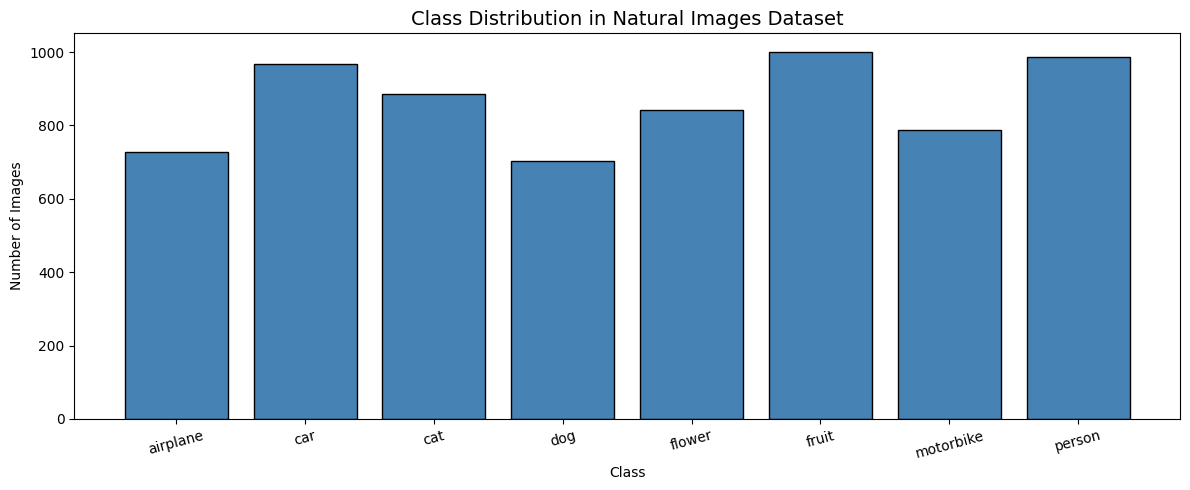

In [11]:
# Count images per class
class_counts = {}
total_images = 0

for class_name in CLASS_NAMES:
    class_path = os.path.join(DATASET_PATH, class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count
    total_images += count

print(f"Total images in dataset: {total_images}\n")
print("Images per class:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} images")

# Plot class distribution
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.title('Class Distribution in Natural Images Dataset', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

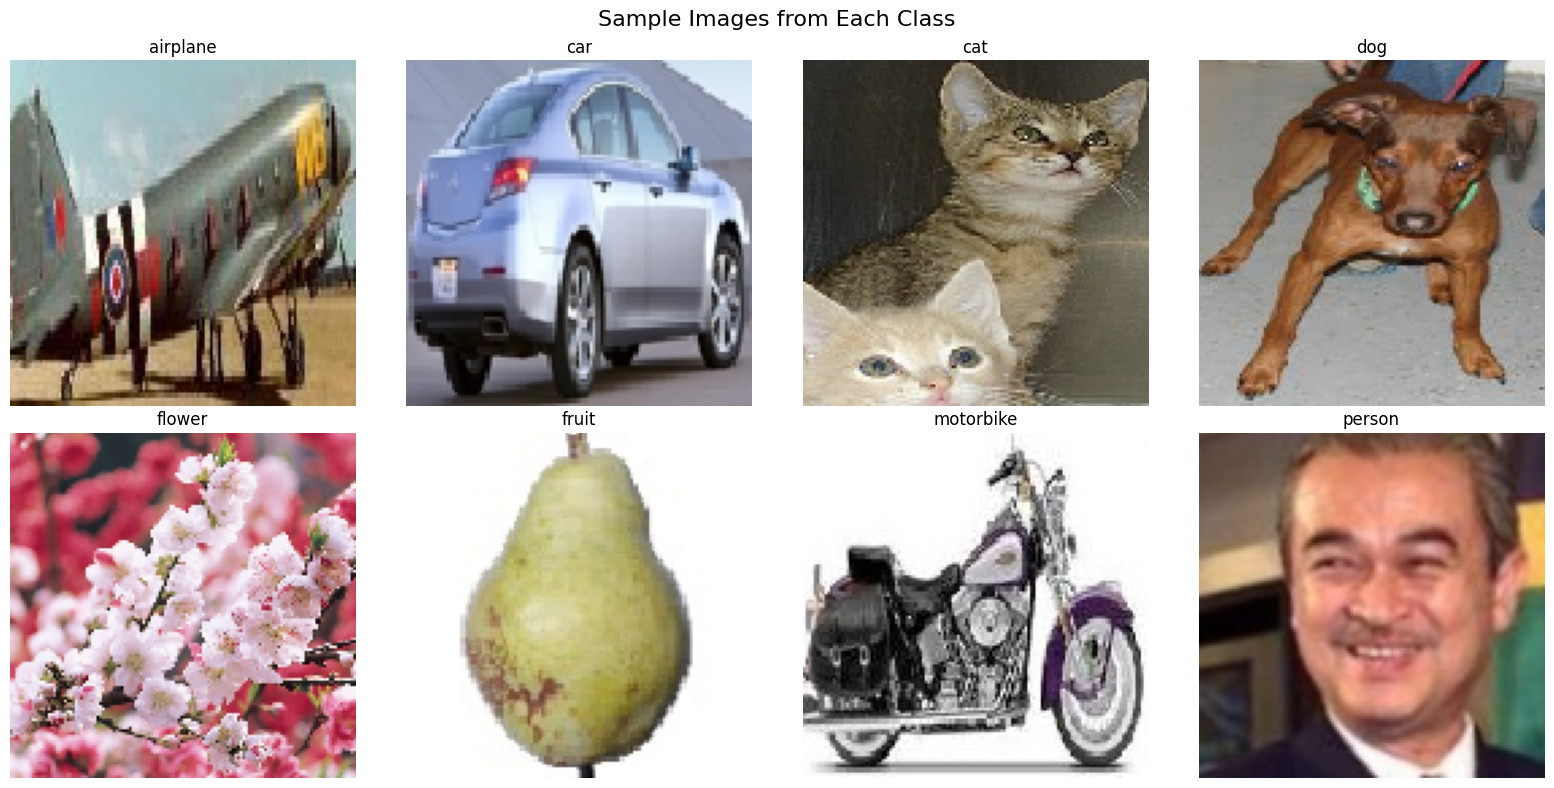

In [12]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_PATH, class_name)
    img_file = os.listdir(class_path)[0]
    img = load_img(os.path.join(class_path, img_file), target_size=(128, 128))
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=12)
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2  # 80% train, 20% validation
)

# Validation data generator (only rescale, no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Found 5524 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.

Training samples: 5524
Validation samples: 1377
Class indices: {'airplane': 0, 'car': 1, 'cat': 2, 'dog': 3, 'flower': 4, 'fruit': 5, 'motorbike': 6, 'person': 7}


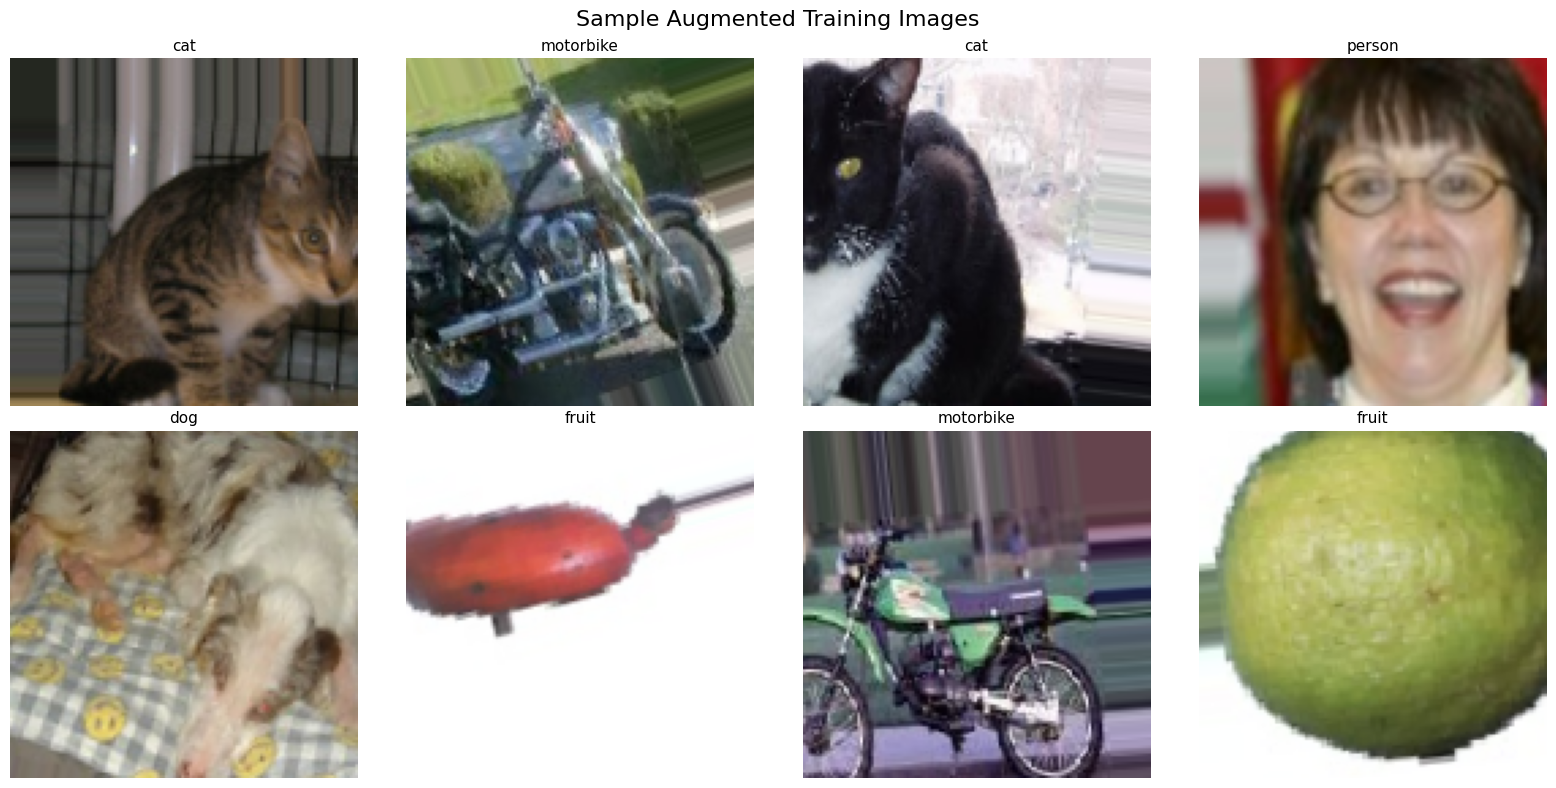

In [7]:
# Show augmented samples
sample_images, sample_labels = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(sample_images[i])
    class_idx = np.argmax(sample_labels[i])
    axes[i].set_title(CLASS_NAMES[class_idx], fontsize=11)
    axes[i].axis('off')

plt.suptitle('Sample Augmented Training Images', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# Baseline CNN Model
def build_baseline_model():
    model = models.Sequential([
        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Flatten
        layers.Flatten(),

        # Fully Connected Layers
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),

        # Output Layer
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,784 (32.52 MB)

 Trainable params: 8,523,784 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/AI/baseline_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train
import time
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

baseline_training_time = time.time() - start_time
print(f"\nBaseline Model Training Time: {baseline_training_time:.2f} seconds")

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.7674 - loss: 0.6546
Epoch 1: val_accuracy improved from None to 0.70443, saving model to /content/drive/MyDrive/AI/baseline_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI/baseline_best.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.7654 - loss: 0.6441 - val_accuracy: 0.7044 - val_loss: 0.8783
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.7999 - loss: 0.5508
Epoch 2: val_accuracy improved from 0.70443 to 0.84459, saving model to /content/drive/MyDrive/AI/baseline_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI/baseline_best.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 50s 288ms/step - accuracy: 0.8041 - loss: 0.5275 - val_accuracy: 0.8446 - val_loss: 0.4464
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8165 - loss: 0.4913
Epoch 3: val_accuracy did not improve from 0.84459
173/173 ━━━━━━━━━━━━━━━━━━━━ 51s 292ms/step - accura

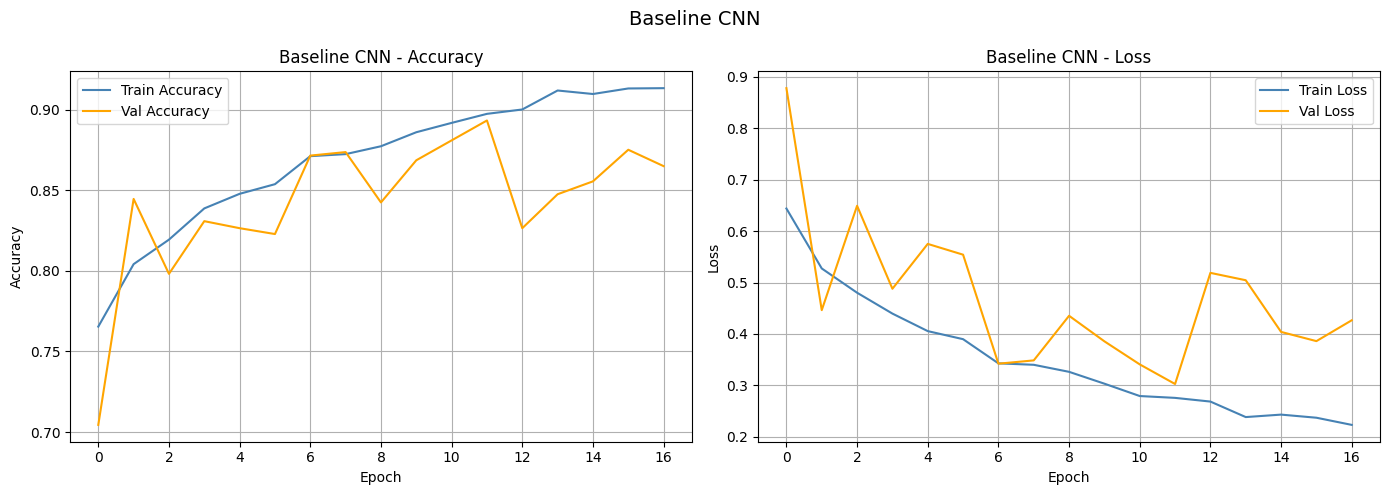

In [19]:
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, title='Baseline CNN')

44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.8932 - loss: 0.3027

Baseline Model - Validation Accuracy: 89.32%
Baseline Model - Validation Loss: 0.3027
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.96      0.63      0.76       145
         car       0.83      0.98      0.90       193
         cat       0.78      0.88      0.83       177
         dog       0.85      0.59      0.70       140
      flower       0.96      0.95      0.95       168
       fruit       0.99      1.00      0.99       200
   motorbike       0.84      0.99      0.91       157
      person       0.97      0.99      0.98       197

    accuracy                           0.89      1377
   macro avg       0.90      0.88      0.88      1377
weighted avg       0.90      0.89      0.89      1377



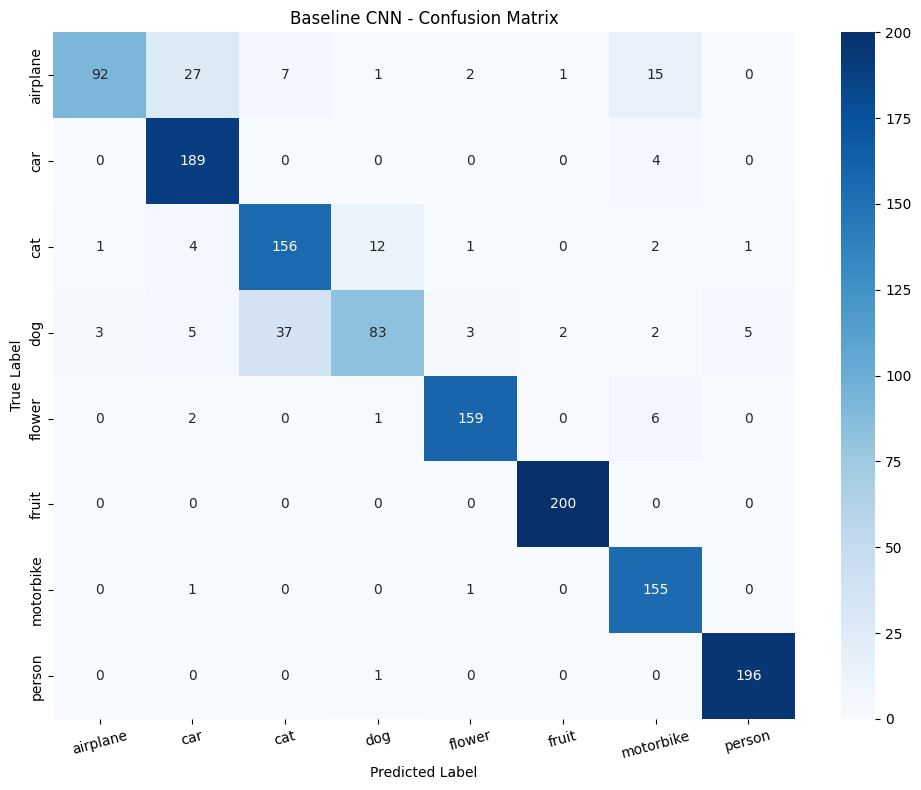

In [20]:
# Evaluate on validation set
val_generator.reset()
baseline_loss, baseline_acc = baseline_model.evaluate(val_generator, verbose=1)
print(f"\nBaseline Model - Validation Accuracy: {baseline_acc*100:.2f}%")
print(f"Baseline Model - Validation Loss: {baseline_loss:.4f}")

# Predictions
val_generator.reset()
y_pred = baseline_model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Baseline CNN - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step


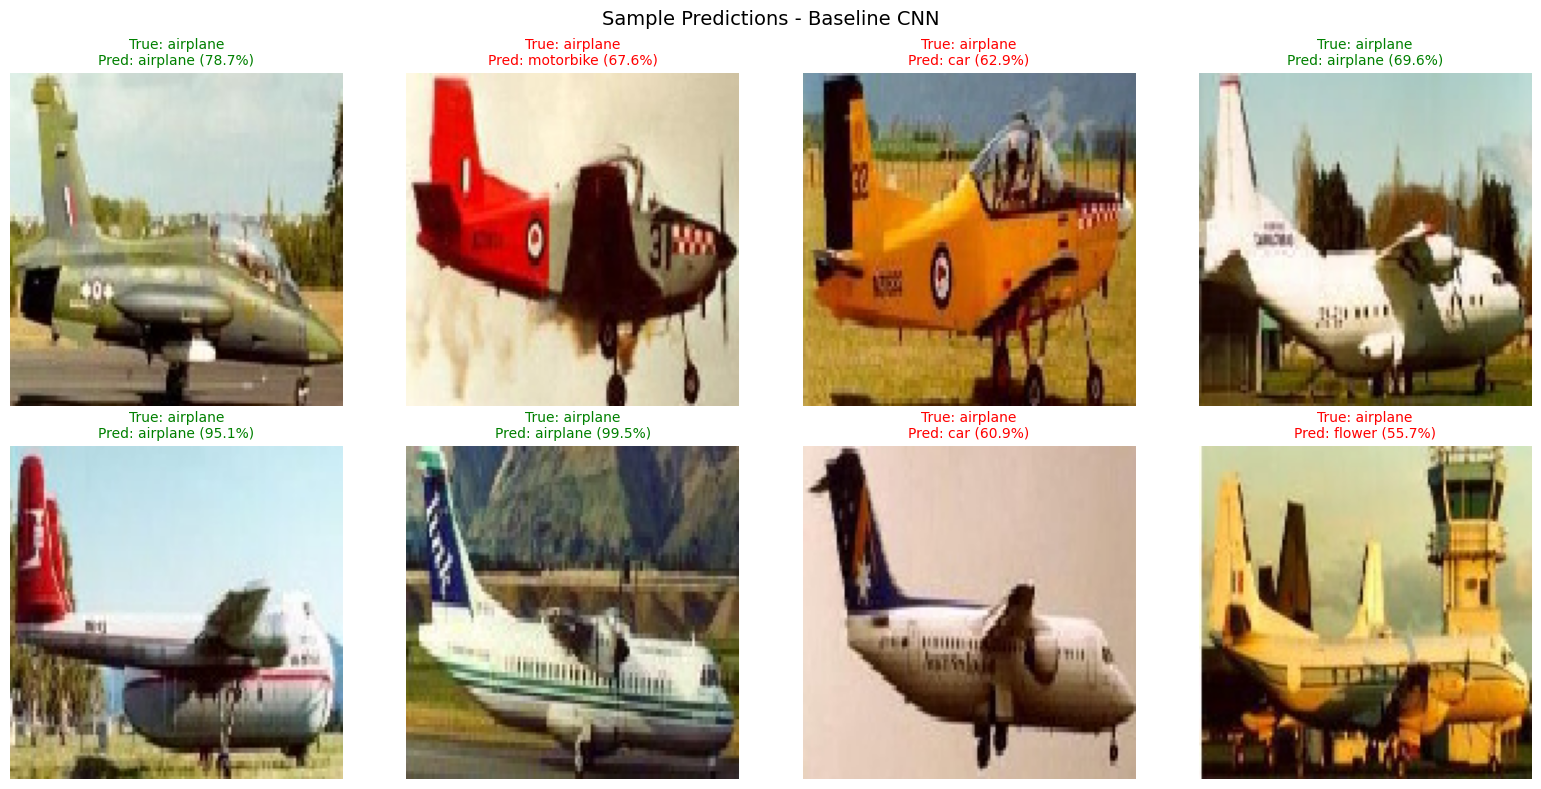

In [21]:
# Run inference on sample images and display predictions
def predict_samples(model, generator, class_names, n=8):
    generator.reset()
    images, labels = next(generator)
    predictions = model.predict(images[:n])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(images[i])
        true_label = class_names[np.argmax(labels[i])]
        pred_label = class_names[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                          color=color, fontsize=10)
        axes[i].axis('off')

    plt.suptitle('Sample Predictions - Baseline CNN', fontsize=14)
    plt.tight_layout()
    plt.show()

val_generator.reset()
predict_samples(baseline_model, val_generator, CLASS_NAMES)

In [22]:
def build_deeper_model():
    model = models.Sequential([
        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Convolutional Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Convolutional Block 5
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Flatten
        layers.Flatten(),

        # Fully Connected Layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        # Output Layer
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

deeper_model = build_deeper_model()
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,079,336 (34.63 MB)

 Trainable params: 9,075,816 (34.62 MB)

 Non-trainable params: 3,520 (13.75 KB)

In [23]:
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
early_stop_deeper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_deeper = ModelCheckpoint(
    '/content/drive/MyDrive/AI/deeper_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_deeper, checkpoint_deeper],
    verbose=1
)

deeper_training_time = time.time() - start_time
print(f"\nDeeper Model Training Time: {deeper_training_time:.2f} seconds")

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.3111 - loss: 2.2117
Epoch 1: val_accuracy improved from None to 0.12854, saving model to /content/drive/MyDrive/AI/deeper_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI/deeper_best.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 99s 415ms/step - accuracy: 0.4222 - loss: 1.7654 - val_accuracy: 0.1285 - val_loss: 3.5654
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5923 - loss: 1.1662
Epoch 2: val_accuracy improved from 0.12854 to 0.14524, saving model to /content/drive/MyDrive/AI/deeper_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI/deeper_best.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 310ms/step - accuracy: 0.6106 - loss: 1.0973 - val_accuracy: 0.1452 - val_loss: 5.9544
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.6762 - loss: 0.9179
Epoch 3: val_accuracy improved from 0.14524 to 0.57734, saving model to /content/drive/MyDrive/AI/deeper_best

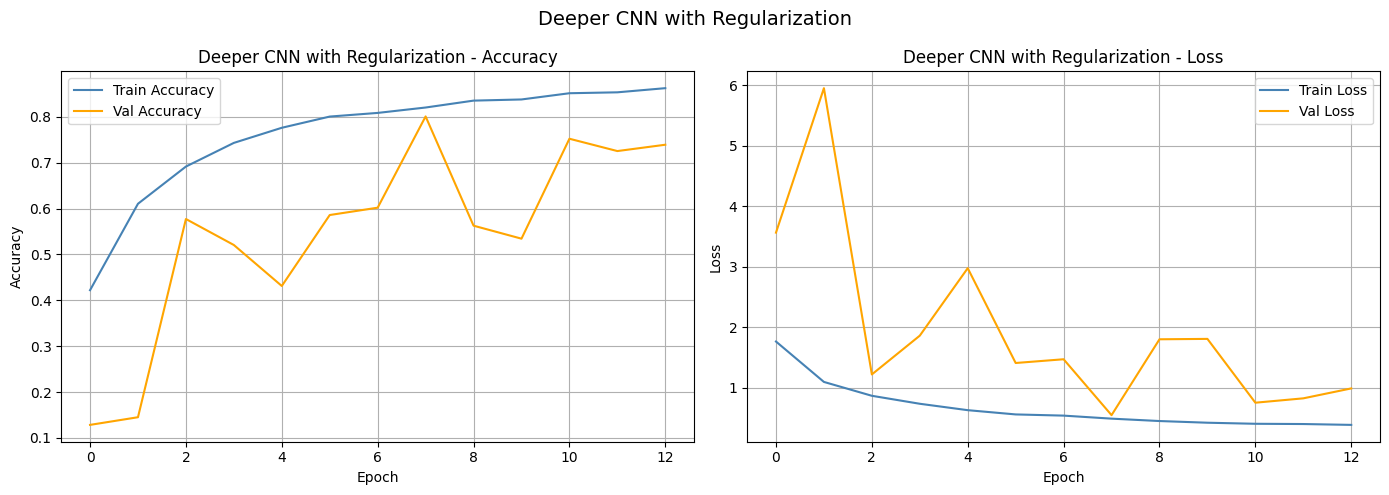

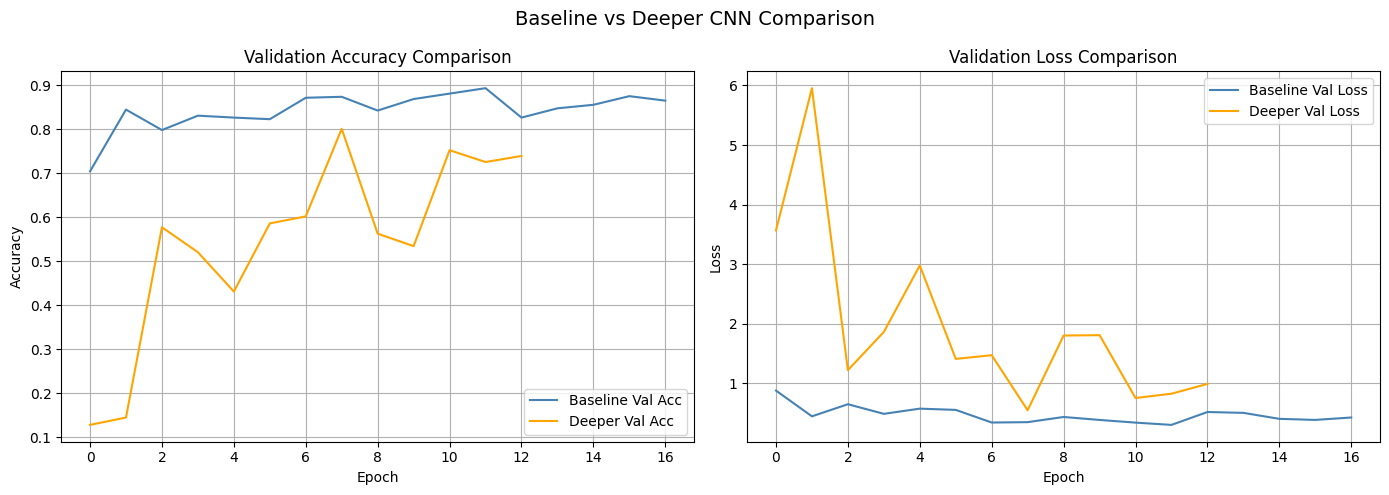

In [25]:
# Plot deeper model curves
plot_history(deeper_history, title='Deeper CNN with Regularization')

# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(baseline_history.history['val_accuracy'], label='Baseline Val Acc', color='steelblue')
axes[0].plot(deeper_history.history['val_accuracy'], label='Deeper Val Acc', color='orange')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss comparison
axes[1].plot(baseline_history.history['val_loss'], label='Baseline Val Loss', color='steelblue')
axes[1].plot(deeper_history.history['val_loss'], label='Deeper Val Loss', color='orange')
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Baseline vs Deeper CNN Comparison', fontsize=14)
plt.tight_layout()
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.8010 - loss: 0.5480

Deeper Model - Validation Accuracy: 80.10%
Deeper Model - Validation Loss: 0.5480
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step

Classification Report - Deeper Model:
              precision    recall  f1-score   support

    airplane       0.89      0.83      0.86       145
         car       0.78      0.95      0.85       193
         cat       0.65      0.67      0.66       177
         dog       0.50      0.44      0.47       140
      flower       0.71      0.96      0.82       168
       fruit       0.98      0.96      0.97       200
   motorbike       0.93      0.78      0.85       157
      person       0.99      0.73      0.84       197

    accuracy                           0.80      1377
   macro avg       0.80      0.79      0.79      1377
weighted avg       0.81      0.80      0.80      1377



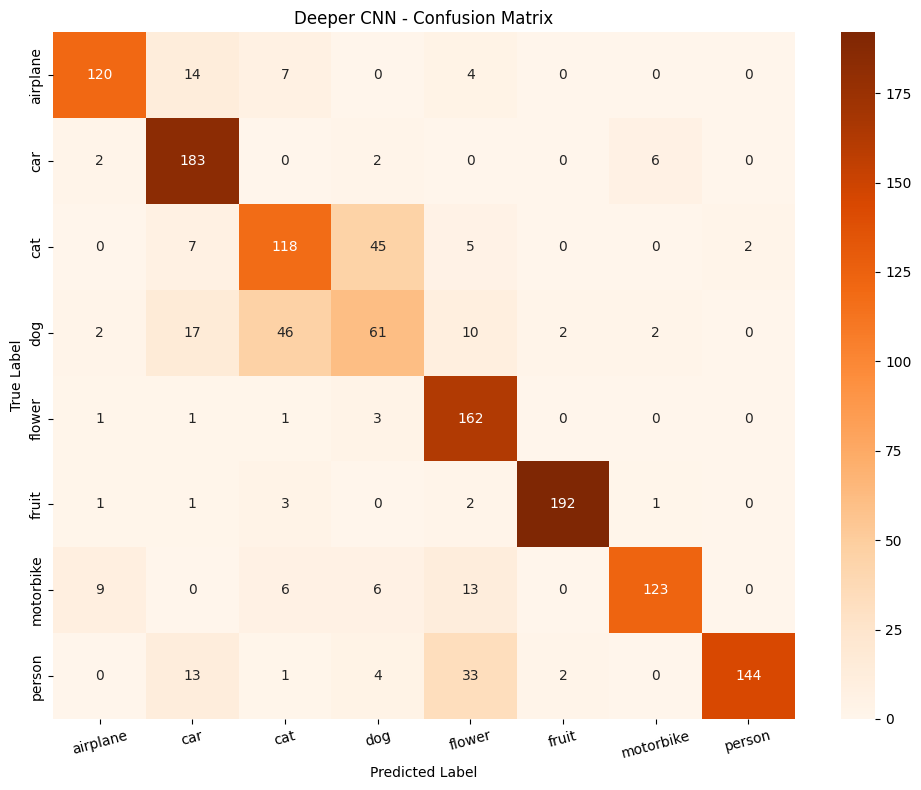

In [26]:
val_generator.reset()
deeper_loss, deeper_acc = deeper_model.evaluate(val_generator, verbose=1)
print(f"\nDeeper Model - Validation Accuracy: {deeper_acc*100:.2f}%")
print(f"Deeper Model - Validation Loss: {deeper_loss:.4f}")

# Classification Report
val_generator.reset()
y_pred_deeper = deeper_model.predict(val_generator, verbose=1)
y_pred_deeper_classes = np.argmax(y_pred_deeper, axis=1)
y_true = val_generator.classes

print("\nClassification Report - Deeper Model:")
print(classification_report(y_true, y_pred_deeper_classes, target_names=CLASS_NAMES))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_deeper = confusion_matrix(y_true, y_pred_deeper_classes)
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Deeper CNN - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [27]:
# Train deeper model with SGD
def build_deeper_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# SGD Model
sgd_model = build_deeper_model()
sgd_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_sgd = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

start_time = time.time()
sgd_history = sgd_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_sgd],
    verbose=1
)
sgd_training_time = time.time() - start_time
print(f"\nSGD Model Training Time: {sgd_training_time:.2f} seconds")

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 79s 377ms/step - accuracy: 0.3273 - loss: 1.9416 - val_accuracy: 0.3261 - val_loss: 2.2303
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 52s 302ms/step - accuracy: 0.4638 - loss: 1.4562 - val_accuracy: 0.1888 - val_loss: 2.6180
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 51s 297ms/step - accuracy: 0.5250 - loss: 1.2626 - val_accuracy: 0.4568 - val_loss: 1.5411
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 53s 304ms/step - accuracy: 0.6048 - loss: 1.0985 - val_accuracy: 0.4582 - val_loss: 1.4539
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 52s 299ms/step - accuracy: 0.6571 - loss: 0.9555 - val_accuracy: 0.2484 - val_loss: 3.9989
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 52s 302ms/step - accuracy: 0.7000 - loss: 0.8481 - val_accuracy: 0.4161 - val_loss: 2.5075
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 52s 300ms/step - accuracy: 0.7230 - loss: 0.7706 - val_accuracy: 0.4822 - val_loss: 1.8946
Epoch 8/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 52s 298ms/step - accuracy: 0.7457 - loss: 0

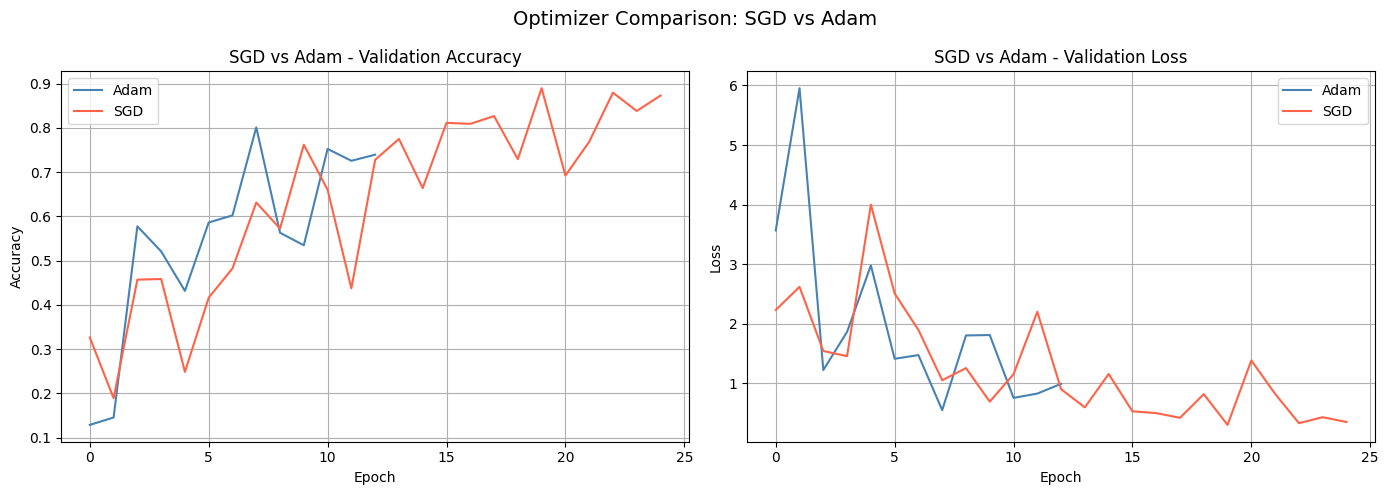

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(deeper_history.history['val_accuracy'], label='Adam', color='steelblue')
axes[0].plot(sgd_history.history['val_accuracy'], label='SGD', color='tomato')
axes[0].set_title('SGD vs Adam - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(deeper_history.history['val_loss'], label='Adam', color='steelblue')
axes[1].plot(sgd_history.history['val_loss'], label='SGD', color='tomato')
axes[1].set_title('SGD vs Adam - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Optimizer Comparison: SGD vs Adam', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# Build deeper model without dropout
def build_no_dropout_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

ablation_model = build_no_dropout_model()
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_abl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

start_time = time.time()
ablation_history = ablation_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_abl],
    verbose=1
)
ablation_training_time = time.time() - start_time
print(f"\nAblation Model Training Time: {ablation_training_time:.2f} seconds")

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 73s 354ms/step - accuracy: 0.6861 - loss: 0.9059 - val_accuracy: 0.1285 - val_loss: 5.1680
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 53s 305ms/step - accuracy: 0.7786 - loss: 0.6034 - val_accuracy: 0.1816 - val_loss: 5.9086
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 310ms/step - accuracy: 0.8177 - loss: 0.4863 - val_accuracy: 0.7429 - val_loss: 0.8721
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.8440 - loss: 0.4248 - val_accuracy: 0.7640 - val_loss: 0.8411
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 53s 307ms/step - accuracy: 0.8546 - loss: 0.3994 - val_accuracy: 0.7313 - val_loss: 0.9620
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 53s 307ms/step - accuracy: 0.8660 - loss: 0.3626 - val_accuracy: 0.8076 - val_loss: 0.6386
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 53s 304ms/step - accuracy: 0.8744 - loss: 0.3408 - val_accuracy: 0.6485 - val_loss: 1.5156
Epoch 8/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.8798 - loss: 0

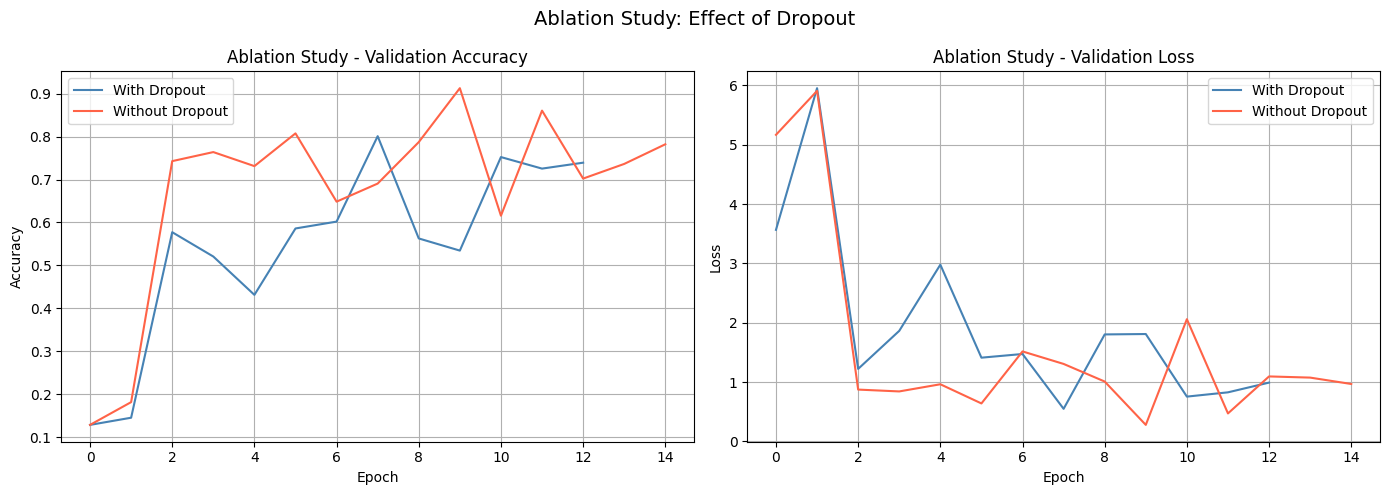

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_accuracy'], label='With Dropout', color='steelblue')
axes[0].plot(ablation_history.history['val_accuracy'], label='Without Dropout', color='tomato')
axes[0].set_title('Ablation Study - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(deeper_history.history['val_loss'], label='With Dropout', color='steelblue')
axes[1].plot(ablation_history.history['val_loss'], label='Without Dropout', color='tomato')
axes[1].set_title('Ablation Study - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Ablation Study: Effect of Dropout', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
# Summary table of all models
print("=" * 65)
print(f"{'Model':<30} {'Val Accuracy':>15} {'Training Time':>15}")
print("=" * 65)
print(f"{'Baseline CNN':<30} {baseline_acc*100:>14.2f}% {baseline_training_time:>13.2f}s")
print(f"{'Deeper CNN (Adam)':<30} {deeper_acc*100:>14.2f}% {deeper_training_time:>13.2f}s")
print(f"{'Deeper CNN (SGD)':<30} {sgd_model.evaluate(val_generator, verbose=0)[1]*100:>14.2f}% {sgd_training_time:>13.2f}s")
print(f"{'Deeper CNN (No Dropout)':<30} {ablation_model.evaluate(val_generator, verbose=0)[1]*100:>14.2f}% {ablation_training_time:>13.2f}s")
print("=" * 65)

Model                             Val Accuracy   Training Time
Baseline CNN                            89.32%       1035.42s
Deeper CNN (Adam)                       80.10%        748.96s
Deeper CNN (SGD)                        88.96%       1339.75s
Deeper CNN (No Dropout)                 91.29%        826.70s


In [32]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

# Load pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze base model layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)
transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,147,208 (92.11 MB)

 Trainable params: 558,984 (2.13 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [33]:
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_transfer = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

checkpoint_transfer = ModelCheckpoint(
    '/content/drive/MyDrive/AI/transfer_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

start_time = time.time()
transfer_history = transfer_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop_transfer, checkpoint_transfer],
    verbose=1
)
transfer_training_time = time.time() - start_time
print(f"\nTransfer Learning Training Time: {transfer_training_time:.2f} seconds")

Epoch 1/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.3658 - loss: 1.7209
Epoch 1: val_accuracy improved from None to 0.17429, saving model to /content/drive/MyDrive/AI/transfer_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI/transfer_best.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 82s 390ms/step - accuracy: 0.4365 - loss: 1.5284 - val_accuracy: 0.1743 - val_loss: 2.0060
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.5548 - loss: 1.2458
Epoch 2: val_accuracy improved from 0.17429 to 0.44227, saving model to /content/drive/MyDrive/AI/transfer_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI/transfer_best.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 308ms/step - accuracy: 0.5574 - loss: 1.2272 - val_accuracy: 0.4423 - val_loss: 1.3932
Epoch 3/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.5742 - loss: 1.1574
Epoch 3: val_accuracy did not improve from 0.44227
173/173 ━━━━━━━━━━━━━━━━━━━━ 81s 306ms/step - accu

In [34]:
# Unfreeze last 30 layers of ResNet50
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

start_time = time.time()
finetune_history = transfer_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop_ft],
    verbose=1
)
finetune_training_time = time.time() - start_time
print(f"\nFine Tuning Training Time: {finetune_training_time:.2f} seconds")

Epoch 1/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 93s 405ms/step - accuracy: 0.5060 - loss: 1.4315 - val_accuracy: 0.3922 - val_loss: 2.5140
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 55s 316ms/step - accuracy: 0.6054 - loss: 1.1100 - val_accuracy: 0.5207 - val_loss: 1.4505
Epoch 3/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 311ms/step - accuracy: 0.6325 - loss: 1.0030 - val_accuracy: 0.5621 - val_loss: 1.2772
Epoch 4/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 55s 316ms/step - accuracy: 0.6665 - loss: 0.9543 - val_accuracy: 0.6616 - val_loss: 1.0757
Epoch 5/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 55s 316ms/step - accuracy: 0.6828 - loss: 0.9089 - val_accuracy: 0.6471 - val_loss: 1.2188
Epoch 6/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 55s 315ms/step - accuracy: 0.6917 - loss: 0.8561 - val_accuracy: 0.4873 - val_loss: 1.9116
Epoch 7/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 53s 309ms/step - accuracy: 0.7000 - loss: 0.8375 - val_accuracy: 0.6507 - val_loss: 1.5034
Epoch 8/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 52s 302ms/step - accuracy: 0.7085 - loss: 0

44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.7618 - loss: 0.6807

Transfer Model - Validation Accuracy: 76.18%
Transfer Model - Validation Loss: 0.6807
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step

Classification Report - Transfer Learning:
              precision    recall  f1-score   support

    airplane       0.96      0.59      0.73       145
         car       0.80      0.97      0.88       193
         cat       0.86      0.29      0.43       177
         dog       0.59      0.60      0.59       140
      flower       1.00      0.58      0.73       168
       fruit       0.98      0.98      0.98       200
   motorbike       0.79      0.96      0.87       157
      person       0.54      0.99      0.70       197

    accuracy                           0.76      1377
   macro avg       0.82      0.75      0.74      1377
weighted avg       0.82      0.76      0.75      1377



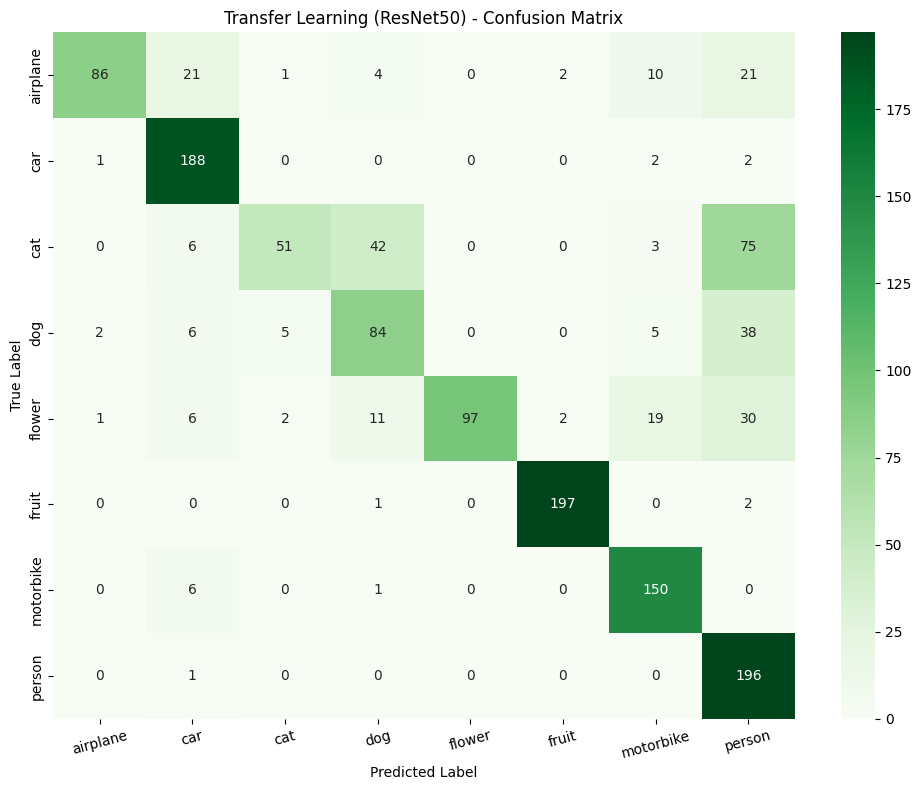

In [37]:
val_generator.reset()
transfer_loss, transfer_acc = transfer_model.evaluate(val_generator, verbose=1)
print(f"\nTransfer Model - Validation Accuracy: {transfer_acc*100:.2f}%")
print(f"Transfer Model - Validation Loss: {transfer_loss:.4f}")

val_generator.reset()
y_pred_transfer = transfer_model.predict(val_generator, verbose=1)
y_pred_transfer_classes = np.argmax(y_pred_transfer, axis=1)
y_true = val_generator.classes

print("\nClassification Report - Transfer Learning:")
print(classification_report(y_true, y_pred_transfer_classes, target_names=CLASS_NAMES))

plt.figure(figsize=(10, 8))
cm_transfer = confusion_matrix(y_true, y_pred_transfer_classes)
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Transfer Learning (ResNet50) - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [36]:
val_generator.reset()
transfer_eval = transfer_model.evaluate(val_generator, verbose=0)

print("=" * 65)
print(f"{'Model':<30} {'Val Accuracy':>15} {'Training Time':>15}")
print("=" * 65)
print(f"{'Baseline CNN':<30} {baseline_acc*100:>14.2f}% {baseline_training_time:>13.2f}s")
print(f"{'Deeper CNN (Adam)':<30} {deeper_acc*100:>14.2f}% {deeper_training_time:>13.2f}s")
print(f"{'Deeper CNN (SGD)':<30} {sgd_model.evaluate(val_generator, verbose=0)[1]*100:>14.2f}% {sgd_training_time:>13.2f}s")
print(f"{'Deeper CNN (No Dropout)':<30} {ablation_model.evaluate(val_generator, verbose=0)[1]*100:>14.2f}% {ablation_training_time:>13.2f}s")
print(f"{'ResNet50 Transfer Learning':<30} {transfer_eval[1]*100:>14.2f}% {transfer_training_time:>13.2f}s")
print("=" * 65)

Model                             Val Accuracy   Training Time
Baseline CNN                            89.32%       1035.42s
Deeper CNN (Adam)                       80.10%        748.96s
Deeper CNN (SGD)                        88.96%       1339.75s
Deeper CNN (No Dropout)                 91.29%        826.70s
ResNet50 Transfer Learning              76.18%        435.98s
